# Notebook for constructing age models for the North Shore Volcanics Northeast Sequence

In [ ]:
using Pkg
Pkg.activate("../")
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

plot_posterior_paths (generic function with 1 method)

## North Shore Volcanics Northeast Sequence

This strat is different from the one in Green, 2011

Boerboom and Green, 2011 Kadunce River map

Marr Island lavas—A thick (approximately 3,200 feet [975 meters]) sequence of mafic to intermediate lava flows (Green, 2002), which extend westward from the Marr Island quadrangle into this map area.

Kimball Creek felsites—An informal lithostratigraphic term for two relatively thick flow sequences—the approximately 984-foot (300-meter) thick Kimball Creek rhyolite, the underlying, approximately 1,601-foot (488-meter) thick Kadunce icelandites, and a thin basal flow of porphyritic rhyolite referred to as "porphyritic quartz latite" by Fitz (1988) that is approximately 210 feet (64 meters) thick. A more detailed description of the Kimball Creek felsites can be found in Fitz (1988).

198 m Naniboujou basalt
975 m Marr Island lavas
64 m porphyritic rhyolite
488 m Kadunce icelandites
300 m Kimball Creek rhyolite 

In [2]:
NSVG_NE_Name = ("Grand Portage lavas base", "Red Rock rhyolite", "Devil's Kettle rhyolite", "Grand Marais rhyolite", "Silver Bay Intrusion") # Et cetera
NSVG_NE_Age           = [ 1110, 1105.6, 1095.40, 1093.53, 1091.61] # Measured ages
NSVG_NE_Age_sigma     = [ 2/2,   0.32/2,  0.44/2,  0.43/2, 0.14/2] # Measured 1-σ uncertainties
NSVG_NE_Height        = [ 0,     1037,      3936,    7170, 7847] # Depths below surface should be negative
NSVG_NE_Age_Sidedness = [0, 0, 0, 0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

NSVG_NE_Path = "../../data/age_models_output/NSVG_NE" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
NSVG_NE_section = make_ChronAgeData(NSVG_NE_Name, NSVG_NE_Age, NSVG_NE_Age_sigma, NSVG_NE_Height, NSVG_NE_Age_Sidedness, NSVG_NE_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{5}(("Grand Portage lavas base", "Red Rock rhyolite", "Devil's Kettle rhyolite", "Grand Marais rhyolite", "Silver Bay Intrusion"), [0.0, 1037.0, 3936.0, 7170.0, 7847.0], [0.01, 0.01, 0.01, 0.01, 0.01], [1110.0, 1105.6, 1095.4, 1093.53, 1091.61], [1.0, 0.16, 0.22, 0.215, 0.07], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0], [#undef, #undef, #undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer, :Chronometer, :Chronometer), [NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN NaN; NaN NaN … NaN NaN], "../../data/age_models_output/NSVG_NE", 2, "Ma", "m", :cdf)

In [3]:
NSVG_NE_age_model_config, NSVG_NE_age_model_mdl, NSVG_NE_age_model_agedist, NSVG_NE_age_model_lldist = run_age_model(NSVG_NE_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 1099000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 1099000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 1099000, 1000, 1099, 0.2), StratAgeModel([0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0  …  7750.0, 7760.0, 7770.0, 7780.0, 7790.0, 7800.0, 7810.0, 7820.0, 7830.0, 7840.0], [1109.607545620956, 1109.563210103672, 1109.5277700301942, 1109.4803278774123, 1109.445760522462, 1109.414194373225, 1109.386937651495, 1109.3568544303623, 1109.3253175815385, 1109.2948782186043  …  1092.0285635518765, 1091.9979387098206, 1091.9656022589324, 1091.9288798983994, 1091.8954563261027, 1091.853957386852, 1091.817216372182, 1091.7828807056485, 1091.7294459190316, 1091.6708638164703], [0.81020920444814, 0.8430526241567368, 0.8699271004006917, 0.8948214441096596, 0.9062434859672781, 0.9228598860580685, 0.9270930573696827, 0.9367898305094484, 0.9524979023933012, 0.963044746292488  …  0.47501699635294925, 0.46525228324708395, 0.4503881700777996, 0.42919215303454283, 0.40442235280883126, 0.3756523238061681, 0.35721254898802185, 0.333514207013795, 0.2813080594376411

### posterior summary age model

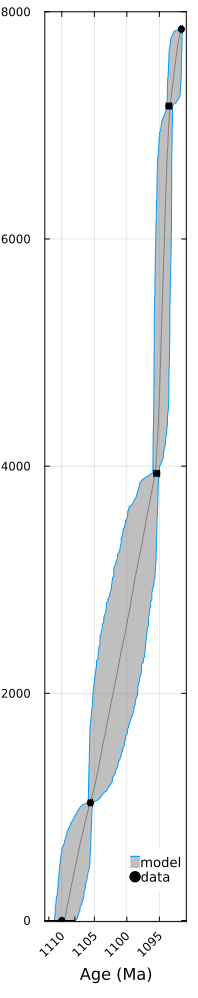

In [4]:
NSVG_NE_age_model = plot_age_model(NSVG_NE_section, NSVG_NE_age_model_mdl, save_figure=false)
plot!(ylim=(-10, 8000))
savefig(NSVG_NE_age_model, NSVG_NE_section.Path*"_AgeDepthModel.pdf")
display(NSVG_NE_age_model)

### example posterior accumulation models

  0.010644 seconds (17.00 k allocations: 22.049 MiB, 61.10% gc time)


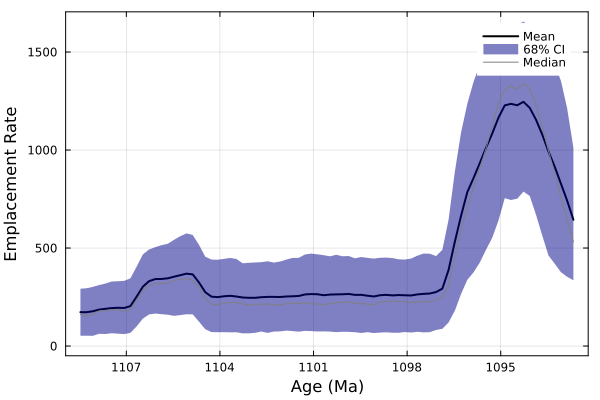

In [5]:
plot_accumulation_model(NSVG_NE_section, NSVG_NE_age_model_config, NSVG_NE_age_model_mdl, NSVG_NE_age_model_agedist, save_figure=false)

### example posterior age models

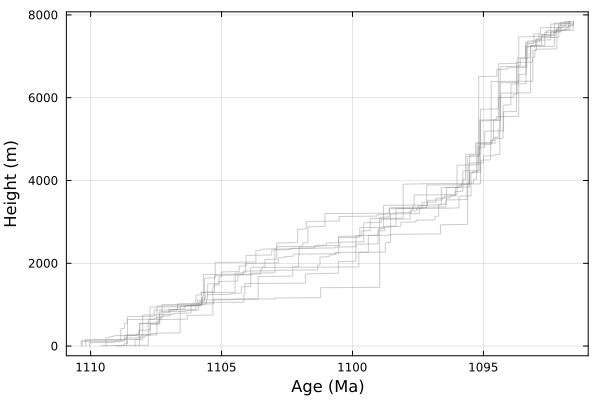

In [6]:
plot_posterior_paths(NSVG_NE_section, NSVG_NE_age_model_agedist, NSVG_NE_age_model_mdl)

## save the age models to a file

In [7]:
NSVG_NE_age_model_agedist

785×1000 Matrix{Float64}:
 1109.81  1109.67  1110.25  1110.05  …  1110.04  1108.44  1109.13  1109.42
 1109.81  1109.67  1110.25  1109.22     1110.04  1108.44  1109.13  1109.42
 1109.81  1109.0   1110.25  1109.22     1110.04  1108.44  1109.13  1109.42
 1109.81  1109.0   1110.25  1109.22     1110.04  1108.44  1109.13  1109.42
 1109.81  1109.0   1110.25  1109.22     1110.04  1108.44  1109.13  1109.42
 1109.81  1108.21  1110.25  1109.22  …  1110.04  1108.44  1109.13  1109.42
 1108.98  1108.21  1109.85  1109.22     1110.04  1108.44  1109.13  1108.94
 1108.98  1108.21  1109.85  1109.22     1110.04  1108.44  1109.13  1108.94
 1108.98  1108.21  1109.85  1109.22     1110.04  1108.44  1109.13  1108.94
 1108.95  1108.21  1109.85  1109.22     1110.04  1108.44  1109.13  1108.94
    ⋮                                ⋱                             
 1092.26  1091.64  1091.64  1091.74     1091.74  1091.67  1092.06  1092.17
 1092.26  1091.64  1091.64  1091.73     1091.74  1091.67  1091.87  1092.17
 1092.

In [8]:
# use the mdl.height as index, agedist as the data
NSVG_NE_age_models_df = DataFrame(hcat(NSVG_NE_age_model_mdl.Height, NSVG_NE_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(NSVG_NE_age_models_df, Dict(:x1 => "height"))
NSVG_NE_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1109.81,1109.67,1110.25,1110.05,1110.35,1111.53,1110.59,1109.74,1109.21,1110.33,1108.94,1111.37,1108.76,1109.02,1109.76,1110.28,1108.64,1108.63,1109.89,1110.05,1107.63,1107.7,1109.33,1109.33,1109.17,1109.01,1109.45,1110.83,1110.72,1108.71,1110.18,1109.91,1110.22,1108.82,1108.99,1110.45,1109.04,1110.19,1109.47,1108.93,1108.62,1110.27,1108.81,1109.08,1110.98,1108.79,1109.92,1109.64,1109.63,1111.41,1109.33,1109.86,1110.13,1110.12,1110.51,1110.2,1109.7,1108.87,1109.87,1109.32,1108.17,1110.02,1110.46,1111.05,1109.78,1108.7,1109.27,1109.55,1109.43,1110.73,1109.37,1110.01,1110.95,1111.01,1108.62,1110.07,1108.97,1110.57,1108.73,1109.96,1110.97,1109.72,1109.82,1108.53,1109.32,1109.58,1110.43,1109.99,1109.09,1110.6,1108.39,1109.61,1109.91,1110.47,1108.79,1110.45,1110.23,1109.85,1109.33,⋯
2,10.0,1109.81,1109.67,1110.25,1109.22,1110.35,1111.53,1110.59,1109.74,1109.21,1110.33,1108.94,1111.37,1108.76,1109.02,1109.76,1110.28,1108.64,1107.77,1109.89,1110.05,1107.63,1107.7,1109.33,1109.33,1109.17,1109.01,1109.45,1110.83,1110.72,1108.71,1110.18,1109.91,1110.22,1108.82,1108.99,1110.45,1109.04,1110.19,1109.47,1108.93,1108.62,1110.27,1108.81,1109.08,1110.98,1108.79,1109.92,1109.64,1109.63,1111.41,1109.33,1109.86,1110.13,1110.12,1110.51,1110.2,1109.7,1108.87,1109.87,1109.32,1108.17,1110.02,1110.46,1111.05,1109.78,1108.7,1109.27,1109.55,1109.43,1110.73,1109.37,1110.01,1110.95,1111.01,1108.62,1110.07,1108.97,1110.57,1108.73,1109.96,1110.59,1109.72,1109.82,1108.53,1108.59,1109.58,1110.43,1109.99,1109.09,1110.6,1108.39,1109.61,1109.15,1110.47,1108.79,1110.45,1110.23,1109.85,1109.33,⋯
3,20.0,1109.81,1109.0,1110.25,1109.22,1110.35,1111.53,1110.59,1109.74,1109.21,1110.33,1108.94,1111.37,1108.76,1109.02,1109.76,1110.28,1108.64,1107.77,1109.89,1110.05,1107.63,1107.7,1109.33,1109.33,1109.17,1109.01,1109.45,1110.16,1110.72,1108.71,1110.18,1109.91,1110.22,1108.82,1108.99,1110.45,1109.04,1110.19,1109.47,1108.93,1108.62,1110.27,1108.81,1109.08,1110.98,1108.79,1109.92,1109.64,1109.63,1111.41,1109.33,1109.86,1110.13,1110.12,1110.51,1110.2,1109.7,1108.87,1109.87,1109.32,1108.17,1110.02,1110.46,1111.05,1109.78,1108.7,1109.27,1109.24,1109.43,1110.73,1109.37,1110.01,1110.95,1111.01,1108.62,1110.07,1108.97,1110.57,1108.73,1109.96,1110.59,1109.72,1109.82,1108.53,1108.59,1109.58,1110.43,1109.99,1109.09,1110.6,1108.39,1109.61,1109.15,1110.47,1108.79,1110.45,1110.23,1109.85,1109.33,⋯
4,30.0,1109.81,1109.0,1110.25,1109.22,1110.35,1111.53,1110.59,1109.74,1109.21,1110.33,1108.94,1111.37,1108.76,1109.02,1109.76,1110.28,1108.64,1107.77,1109.89,1110.05,1107.63,1107.7,1109.33,1109.33,1109.17,1109.01,1109.45,1110.16,1110.72,1108.71,1110.18,1109.91,1110.22,1108.82,1108.99,1110.45,1108.27,1110.19,1109.47,1108.93,1108.62,1109.42,1108.81,1109.08,1110.98,1108.79,1109.92,1109.62,1109.63,1111.41,1108

In [9]:
# write the DataFrame to a csv file
CSV.write(NSVG_NE_section.Path*"_posterior_ages.csv", NSVG_NE_age_models_df)

"../../data/age_models_output/NSVG_NE_posterior_ages.csv"